# 05B — Single Well 1D Poroelasticity with FEniCSx — V3 Stable

Esta é a versão **estável e simplificada** do notebook 05B.

Ela evita os problemas que apareceram nas versões anteriores:

- evita `groupby.apply`;
- preserva `step` e `time_s` manualmente;
- evita estado quebrado do Jupyter;
- usa forma fraca compatível com `DOLFINx complex`;
- usa cache JIT dedicado;
- mantém a lógica poroelástica clara e auditável.

## Modelo físico

Este notebook resolve a difusão de pressão com FEniCSx:

```text
S ∂p/∂t - ∂/∂x((k/μ) ∂p/∂x) = 0
```

Depois calcula uma resposta mecânica didática:

```text
epsilon_poro = α Δp / E
```

e integra a deformação para obter deslocamento:

```text
u(x,t)
```

## Entrada

```text
data/physics_ready/parquet/single_well_fenics_ready/
```

## Saída

```text
data/simulation/parquet/single_well_fenicsx_poroelasticity_1d/
```

## Importante

Este modelo é semiacoplado e didático.

O objetivo é entender:

```text
queda de pressão
↓
difusão de pressão
↓
deformação
↓
deslocamento
↓
compactação
```

# STEP 0 — Environment Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List, Optional
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import dolfinx
import ufl
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_PHYSICS_READY_DIR = Path("../data/physics_ready/parquet/single_well_fenics_ready")
DATA_SIMULATION_DIR = Path("../data/simulation/parquet/single_well_fenicsx_poroelasticity_1d")
REPORT_DIR = Path("../reports/single_well_fenicsx_poroelasticity_1d")

DATA_SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PHYSICS_READY_PARQUET_FILE: Optional[str] = None

JIT_CACHE_DIR = Path("/tmp/fenicsx_poroelasticity_jit_cache_v3")

CLEAR_JIT_CACHE_ON_START = True

if CLEAR_JIT_CACHE_ON_START and JIT_CACHE_DIR.exists():
    shutil.rmtree(JIT_CACHE_DIR)

JIT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("FEniCSx OK")
print("dolfinx version:", dolfinx.__version__)
print(f"DATA_PHYSICS_READY_DIR = {DATA_PHYSICS_READY_DIR.resolve()}")
print(f"DATA_SIMULATION_DIR    = {DATA_SIMULATION_DIR.resolve()}")
print(f"REPORT_DIR             = {REPORT_DIR.resolve()}")
print(f"JIT_CACHE_DIR          = {JIT_CACHE_DIR}")

FEniCSx OK
dolfinx version: 0.10.0.post2
DATA_PHYSICS_READY_DIR = /root/shared/data/physics_ready/parquet/single_well_fenics_ready
DATA_SIMULATION_DIR    = /root/shared/data/simulation/parquet/single_well_fenicsx_poroelasticity_1d
REPORT_DIR             = /root/shared/reports/single_well_fenicsx_poroelasticity_1d
JIT_CACHE_DIR          = /tmp/fenicsx_poroelasticity_jit_cache_v3


## Interpretação

O ambiente está pronto.

Esta versão usa um cache JIT novo para evitar lixo de compilações anteriores.

# STEP 1 — Load Physics-Ready Parquet

In [2]:
def list_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet encontrado em: {data_dir.resolve()}")

    return files


def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print("Colunas duplicadas removidas mantendo a primeira ocorrência:")
        print(sorted(set(duplicated)))
    return df.loc[:, ~df.columns.duplicated()].copy()


physics_files = list_parquet_files(DATA_PHYSICS_READY_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in physics_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in physics_files],
}))

if PHYSICS_READY_PARQUET_FILE is None:
    selected_physics_path = physics_files[0]
else:
    selected_physics_path = DATA_PHYSICS_READY_DIR / PHYSICS_READY_PARQUET_FILE
    if not selected_physics_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_physics_path}")

df = pd.read_parquet(selected_physics_path)
df = make_unique_columns(df).sort_values("DEPTH").reset_index(drop=True)

if "WELL" in df.columns and df["WELL"].notna().any():
    WELL_NAME = str(df["WELL"].dropna().iloc[0])
else:
    WELL_NAME = selected_physics_path.stem.split("_fenics_ready")[0]

print(f"Arquivo selecionado: {selected_physics_path.name}")
print(f"Poço: {WELL_NAME}")
print(f"Shape: {df.shape}")
print(f"Depth min: {df['DEPTH'].min():,.3f}")
print(f"Depth max: {df['DEPTH'].max():,.3f}")

display(df.head())
display(df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_fenics_ready_2350m1_2400m0.parquet,2026-05-08 14:48:38.060850382


Arquivo selecionado: TFT-4_fenics_ready_2350m1_2400m0.parquet
Poço: TFT-4
Shape: (329, 16)
Depth min: 2,350.136
Depth max: 2,399.992


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
0,TFT-4,"2,350.136400","2,409.744322","4,564.744311","2,251.323467",0.334331,"12,256,840,817.437845","33,003,964,238.271610","32,786,153,018.229519","10,988,331.988865","5,424,147.760899",0.219376,"2,350.136400","2,399.992400",0.152000,True
1,TFT-4,"2,350.288400","2,409.362810","4,515.308239","2,218.423544",0.335592,"11,913,293,372.311029","32,545,065,165.444843","31,905,485,503.589760","10,872,226.132795","5,345,663.917131",0.251638,"2,350.136400","2,399.992400",0.152000,True
2,TFT-4,"2,350.440400","2,409.240171","4,464.553345","2,188.575913",0.336538,"11,605,362,566.700142","31,991,636,763.882751","31,103,994,897.294281","10,751,782.908020","5,274,144.908529",0.286587,"2,350.136400","2,399.992400",0.152000,True
3,TFT-4,"2,350.592400","2,409.144786","4,404.476525","2,157.580660",0.337273,"11,293,693,500.715904","31,261,745,368.586189","30,277,976,074.992485","10,609,289.794359","5,200,176.422041",0.318953,"2,350.136400","2,399.992400",0.152000,True
4,TFT-4,"2,350.744400","2,408.905709","4,337.697166","2,129.403432",0.337862,"11,010,394,982.113462","30,394,247,432.326649","29,503,347,628.122078","10,446,856.563887","5,131,202.094845",0.345972,"2,350.136400","2,399.992400",0.152000,True


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
324,TFT-4,"2,399.384400","2,425.259936","3,417.817492","1,865.594885",0.288048,"8,461,479,016.900890","16,970,268,536.367668","21,768,744,085.145435","8,269,377.572994","4,522,558.092900",0.596667,"2,350.136400","2,399.992400",0.152000,True
325,TFT-4,"2,399.536400","2,429.335634","3,428.954997","1,871.179920",0.288117,"8,530,592,123.557176","17,114,040,401.184122","21,941,982,585.864567","8,307,618.998616","4,545,282.536272",0.596311,"2,350.136400","2,399.992400",0.152000,True
326,TFT-4,"2,399.688400","2,434.430257","3,442.876878","1,878.114600",0.288204,"8,613,100,959.222910","17,293,755,232.205284","22,156,411,146.318531","8,355,420.780645","4,572,694.585376",0.595866,"2,350.136400","2,399.992400",0.152000,True
327,TFT-4,"2,399.840400","2,437.703252","3,460.776439","1,886.508270",0.288315,"8,701,405,940.235632","17,524,817,157.804939","22,397,248,085.329918","8,414,959.192313","4,602,911.181458",0.596467,"2,350.136400","2,399.992400",0.152000,True
328,TFT-4,"2,399.992400","2,439.323485","3,484.642521","1,897.699829",0.288398,"8,818,103,024.547861","17,832,899,725.233055","22,718,364,003.972057","8,490,158.764764","4,635,465.171205",0.597377,"2,350.136400","2,399.992400",0.152000,True


## Interpretação

Carregamos os dados `physics-ready`.

Aqui já temos a zona selecionada, com propriedades físicas limpas e preparadas.

# STEP 2 — Select Valid Points and Create Local Coordinate

Pontos válidos: 329
Comprimento da zona L = 49.856000 m


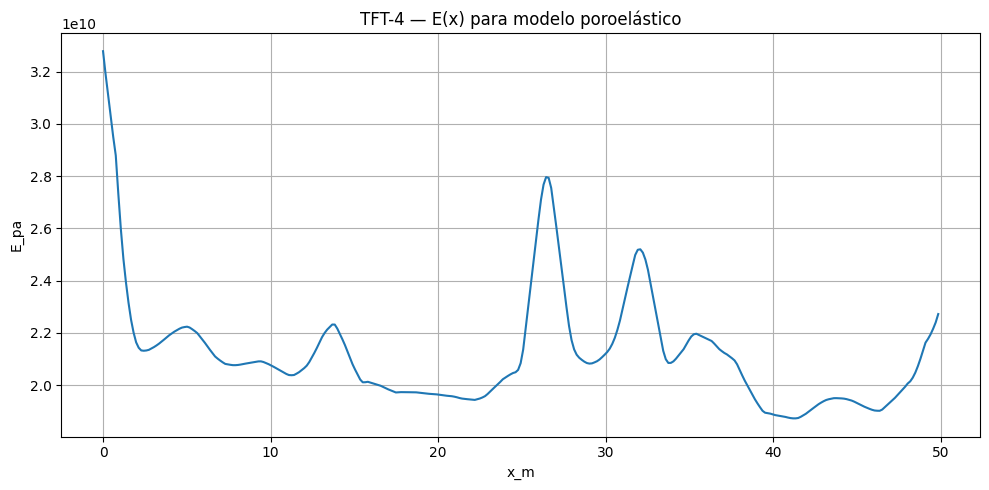

,DEPTH,x_m,E_pa
0,"2,350.136400",0.000000,"32,786,153,018.229519"
1,"2,350.288400",0.152000,"31,905,485,503.589760"
2,"2,350.440400",0.304000,"31,103,994,897.294281"
3,"2,350.592400",0.456000,"30,277,976,074.992485"
4,"2,350.744400",0.608000,"29,503,347,628.122078"


,DEPTH,x_m,E_pa
324,"2,399.384400",49.248000,"21,768,744,085.145435"
325,"2,399.536400",49.400000,"21,941,982,585.864567"
326,"2,399.688400",49.552000,"22,156,411,146.318531"
327,"2,399.840400",49.704000,"22,397,248,085.329918"
328,"2,399.992400",49.856000,"22,718,364,003.972057"


In [3]:
required_cols = ["DEPTH", "E_pa"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Campos obrigatórios ausentes: {missing}")

work_df = df.copy()

if "physics_ready_valid" in work_df.columns:
    work_df = work_df[work_df["physics_ready_valid"].fillna(False).astype(bool)].copy()

work_df = work_df.dropna(subset=["DEPTH", "E_pa"]).sort_values("DEPTH").reset_index(drop=True)

if len(work_df) < 5:
    raise ValueError("Poucos pontos válidos para simulação.")

work_df["x_m"] = work_df["DEPTH"] - work_df["DEPTH"].min()

L = float(work_df["x_m"].max())
N_data = len(work_df)

print(f"Pontos válidos: {N_data:,}")
print(f"Comprimento da zona L = {L:,.6f} m")

plt.figure(figsize=(10, 5))
plt.plot(work_df["x_m"], work_df["E_pa"], "-")
plt.title(f"{WELL_NAME} — E(x) para modelo poroelástico")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.grid(True)
plt.tight_layout()
plt.show()

display(work_df[["DEPTH", "x_m", "E_pa"]].head())
display(work_df[["DEPTH", "x_m", "E_pa"]].tail())

## Interpretação

A coordenada local transforma a zona em:

```text
0 <= x <= L
```

Isso facilita a formulação FEM e a leitura dos resultados.

# STEP 3 — Poroelastic Parameters

In [4]:
BIOT_ALPHA = 0.8

# Armazenamento específico simplificado [1/Pa]
STORAGE_S = 1.0e-9

# Permeabilidade efetiva [m²]
PERMEABILITY_K = 1.0e-14

# Viscosidade do fluido [Pa.s]
FLUID_MU = 1.0e-3

HYDRAULIC_DIFFUSIVITY = PERMEABILITY_K / (FLUID_MU * STORAGE_S)

# Pressões [Pa]
P_INITIAL = 30.0e6
P_TOP = 25.0e6
P_BOTTOM = 30.0e6

# Tempo
TOTAL_TIME_SECONDS = 24 * 3600
N_TIME_STEPS = 24
DT = TOTAL_TIME_SECONDS / N_TIME_STEPS

SELECTED_STEPS = sorted(set([0, 1, 2, 4, 8, 12, N_TIME_STEPS]))

params_df = pd.DataFrame([{
    "BIOT_ALPHA": BIOT_ALPHA,
    "STORAGE_S_1_PA": STORAGE_S,
    "PERMEABILITY_K_M2": PERMEABILITY_K,
    "FLUID_MU_PA_S": FLUID_MU,
    "HYDRAULIC_DIFFUSIVITY_M2_S": HYDRAULIC_DIFFUSIVITY,
    "P_INITIAL_PA": P_INITIAL,
    "P_TOP_PA": P_TOP,
    "P_BOTTOM_PA": P_BOTTOM,
    "TOTAL_TIME_SECONDS": TOTAL_TIME_SECONDS,
    "N_TIME_STEPS": N_TIME_STEPS,
    "DT_SECONDS": DT,
}])

display(params_df)

display(Markdown(f'''
## Interpretação dos parâmetros

- Pressão inicial: **{P_INITIAL/1e6:.1f} MPa**
- Pressão no topo: **{P_TOP/1e6:.1f} MPa**
- Pressão na base: **{P_BOTTOM/1e6:.1f} MPa**

A simulação representa uma queda de pressão no topo da zona.

A difusividade hidráulica é:

```text
D = {HYDRAULIC_DIFFUSIVITY:.2e} m²/s
```
'''))

,BIOT_ALPHA,STORAGE_S_1_PA,PERMEABILITY_K_M2,FLUID_MU_PA_S,HYDRAULIC_DIFFUSIVITY_M2_S,P_INITIAL_PA,P_TOP_PA,P_BOTTOM_PA,TOTAL_TIME_SECONDS,N_TIME_STEPS,DT_SECONDS
0,0.800000,0.000000,0.000000,0.001000,0.010000,"30,000,000.000000","25,000,000.000000","30,000,000.000000",86400,24,"3,600.000000"



## Interpretação dos parâmetros

- Pressão inicial: **30.0 MPa**
- Pressão no topo: **25.0 MPa**
- Pressão na base: **30.0 MPa**

A simulação representa uma queda de pressão no topo da zona.

A difusividade hidráulica é:

```text
D = 1.00e-02 m²/s
```


# STEP 4 — Create Mesh and Function Space

In [5]:
N_CELLS = max(10, N_data - 1)

domain = mesh.create_interval(
    MPI.COMM_WORLD,
    N_CELLS,
    [0.0, L],
)

V = fem.functionspace(domain, ("Lagrange", 1))

print(f"Número de células: {N_CELLS}")
print(f"Número global de DOFs: {V.dofmap.index_map.size_global}")
print(f"Comprimento L: {L:,.6f} m")

Número de células: 328
Número global de DOFs: 329
Comprimento L: 49.856000 m


## Interpretação

Criamos a malha 1D e o espaço funcional.

O campo de pressão será resolvido sobre essa malha.

# STEP 5 — Helper Functions and E(x) Interpolation

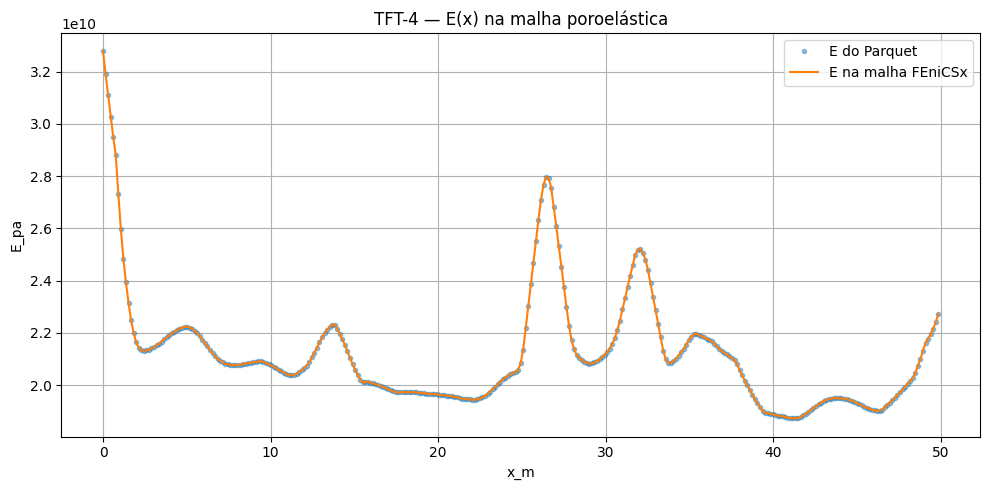

,x_m,E_pa
0,0.000000,"32,786,153,018.229519"
1,0.152000,"31,905,485,503.589760"
2,0.304000,"31,103,994,897.294281"
3,0.456000,"30,277,976,074.992485"
4,0.608000,"29,503,347,628.122078"


,x_m,E_pa
324,49.248000,"21,768,744,085.145435"
325,49.400000,"21,941,982,585.864567"
326,49.552000,"22,156,411,146.318531"
327,49.704000,"22,397,248,085.329918"
328,49.856000,"22,718,364,003.972057"


In [6]:
def function_to_safe_dataframe(V, function, value_name: str) -> pd.DataFrame:
    coords = V.tabulate_dof_coordinates()
    x_coords = coords[:, 0] if coords.ndim == 2 else coords.reshape(-1)
    values = function.x.array.real.copy()
    n = min(len(x_coords), len(values))

    out = pd.DataFrame({
        "x_m": x_coords[:n],
        value_name: values[:n],
    })

    out = (
        out
        .groupby("x_m", as_index=False)
        .agg({value_name: "mean"})
        .sort_values("x_m")
        .reset_index(drop=True)
    )

    return out


def integrate_displacement_from_strain_explicit(group_df: pd.DataFrame) -> pd.DataFrame:
    g = group_df.sort_values("x_m").copy()

    x = g["x_m"].to_numpy(dtype=float)
    eps = g["epsilon_poro"].to_numpy(dtype=float)

    u = np.zeros_like(x)
    u[-1] = 0.0

    for i in range(len(x) - 2, -1, -1):
        dx_i = x[i + 1] - x[i]
        eps_avg = 0.5 * (eps[i + 1] + eps[i])
        u[i] = u[i + 1] - eps_avg * dx_i

    g["u_poro_m"] = u
    g["sigma_effective_pa"] = g["E_pa"] * g["epsilon_poro"]

    return g


x_data = work_df["x_m"].to_numpy(dtype=float)
E_data = work_df["E_pa"].to_numpy(dtype=float)

E_fem = fem.Function(V)
E_fem.name = "E_pa"

def E_interpolator(x):
    return np.interp(x[0], x_data, E_data)

E_fem.interpolate(E_interpolator)

e_df = function_to_safe_dataframe(V, E_fem, "E_pa")

plt.figure(figsize=(10, 5))
plt.plot(x_data, E_data, ".", alpha=0.45, label="E do Parquet")
plt.plot(e_df["x_m"], e_df["E_pa"], "-", label="E na malha FEniCSx")
plt.title(f"{WELL_NAME} — E(x) na malha poroelástica")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display(e_df.head())
display(e_df.tail())

## Interpretação

O módulo de Young foi interpolado para a malha FEM.

Ele será usado para converter queda de pressão em deformação poroelástica.

# STEP 6 — Pressure Diffusion Weak Form

In [7]:
p = ufl.TrialFunction(V)
q = ufl.TestFunction(V)

dx = ufl.dx(domain)

S_const = fem.Constant(domain, PETSc.ScalarType(STORAGE_S))
mobility_const = fem.Constant(domain, PETSc.ScalarType(PERMEABILITY_K / FLUID_MU))
dt_const = fem.Constant(domain, PETSc.ScalarType(DT))

p_old = fem.Function(V)
p_old.name = "p_old"
p_old.x.array[:] = PETSc.ScalarType(P_INITIAL)

# Forma fraca compatível com kernel DOLFINx complex
a_p = (
    S_const * p * ufl.conj(q) * dx
    + dt_const
    * mobility_const
    * ufl.inner(ufl.grad(p), ufl.grad(q))
    * dx
)

L_p = S_const * p_old * ufl.conj(q) * dx

display(Markdown('''
## Interpretação

A forma fraca da difusão de pressão foi montada.

O uso de `ufl.conj(q)` evita erro no kernel `DOLFINx complex`.

O uso de `ufl.inner(grad(p), grad(q))` é a forma correta para o termo difusivo.
'''))


## Interpretação

A forma fraca da difusão de pressão foi montada.

O uso de `ufl.conj(q)` evita erro no kernel `DOLFINx complex`.

O uso de `ufl.inner(grad(p), grad(q))` é a forma correta para o termo difusivo.


# STEP 7 — Boundary Conditions

In [8]:
def top_boundary(x):
    return np.isclose(x[0], 0.0)

def bottom_boundary(x):
    return np.isclose(x[0], L)

top_dofs = fem.locate_dofs_geometrical(V, top_boundary)
bottom_dofs = fem.locate_dofs_geometrical(V, bottom_boundary)

bc_top_p = fem.dirichletbc(fem.Constant(domain, PETSc.ScalarType(P_TOP)), top_dofs, V)
bc_bottom_p = fem.dirichletbc(fem.Constant(domain, PETSc.ScalarType(P_BOTTOM)), bottom_dofs, V)

pressure_bcs = [bc_top_p, bc_bottom_p]

print("Top pressure DOFs:", top_dofs)
print("Bottom pressure DOFs:", bottom_dofs)

Top pressure DOFs: [0]
Bottom pressure DOFs: [328]


## Interpretação

A pressão no topo foi reduzida.

A pressão na base foi mantida.

Isso cria gradiente de pressão e inicia a difusão.

# STEP 8 — Solve Pressure Diffusion in Time

,x_m,p_pa,step,time_s
0,0.000000,"30,000,000.000000",0,0.000000
1,0.152000,"30,000,000.000000",0,0.000000
2,0.304000,"30,000,000.000000",0,0.000000
3,0.456000,"30,000,000.000000",0,0.000000
4,0.608000,"30,000,000.000000",0,0.000000


,x_m,p_pa,step,time_s
2298,49.248000,"29,943,959.112644",24,"86,400.000000"
2299,49.400000,"29,957,969.730083",24,"86,400.000000"
2300,49.552000,"29,971,980.008447",24,"86,400.000000"
2301,49.704000,"29,985,990.060743",24,"86,400.000000"
2302,49.856000,"30,000,000.000000",24,"86,400.000000"


Colunas: ['x_m', 'p_pa', 'step', 'time_s']


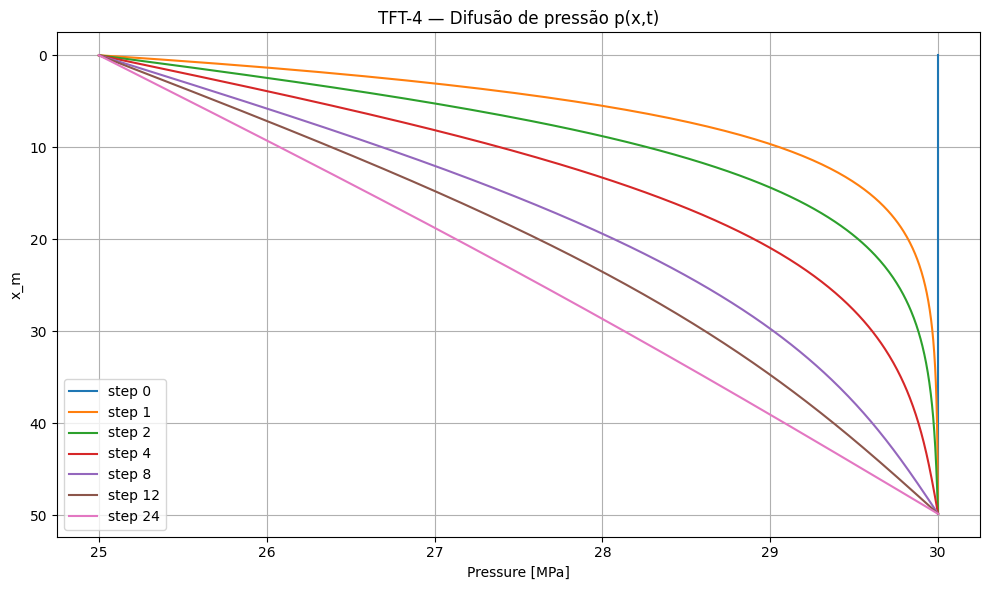

In [9]:
pressure_problem = LinearProblem(
    a_p,
    L_p,
    bcs=pressure_bcs,
    petsc_options_prefix="pressure_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
    jit_options={
        "cache_dir": str(JIT_CACHE_DIR),
        "timeout": 120,
    },
)

pressure_snapshots = []

# Salva estado inicial
initial_snap = function_to_safe_dataframe(V, p_old, "p_pa")
initial_snap["step"] = 0
initial_snap["time_s"] = 0.0
pressure_snapshots.append(initial_snap)

for step in range(1, N_TIME_STEPS + 1):
    p_new = pressure_problem.solve()
    p_new.name = "pressure_p"

    p_old.x.array[:] = p_new.x.array[:]

    if step in SELECTED_STEPS:
        snap = function_to_safe_dataframe(V, p_new, "p_pa")
        snap["step"] = int(step)
        snap["time_s"] = float(step * DT)
        pressure_snapshots.append(snap)

pressure_history_df = pd.concat(pressure_snapshots, ignore_index=True)

# Garantia total de colunas
required_cols = ["x_m", "p_pa", "step", "time_s"]
missing_cols = [c for c in required_cols if c not in pressure_history_df.columns]
if missing_cols:
    raise ValueError(f"Colunas ausentes em pressure_history_df: {missing_cols}")

pressure_history_df = pressure_history_df[required_cols].copy()
pressure_history_df["step"] = pressure_history_df["step"].astype(int)
pressure_history_df["time_s"] = pressure_history_df["time_s"].astype(float)
pressure_history_df = pressure_history_df.sort_values(["step", "x_m"]).reset_index(drop=True)

display(pressure_history_df.head())
display(pressure_history_df.tail())
print("Colunas:", pressure_history_df.columns.tolist())

plt.figure(figsize=(10, 6))
for step_value in sorted(pressure_history_df["step"].unique()):
    g = pressure_history_df[pressure_history_df["step"] == step_value]
    plt.plot(g["p_pa"] / 1e6, g["x_m"], label=f"step {step_value}")

plt.gca().invert_yaxis()
plt.title(f"{WELL_NAME} — Difusão de pressão p(x,t)")
plt.xlabel("Pressure [MPa]")
plt.ylabel("x_m")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretação

A pressão foi resolvida no tempo com FEniCSx.

O gráfico mostra os perfis de pressão em diferentes tempos.

# STEP 9 — Explicit Mechanical Response Loop

,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa
0,0.000000,"30,000,000.000000",0,0.000000,"32,786,153,018.229519",0.000000,0.000000,0.000000,0.000000
1,0.152000,"30,000,000.000000",0,0.000000,"31,905,485,503.589760",0.000000,0.000000,0.000000,0.000000
2,0.304000,"30,000,000.000000",0,0.000000,"31,103,994,897.294281",0.000000,0.000000,0.000000,0.000000
3,0.456000,"30,000,000.000000",0,0.000000,"30,277,976,074.992485",0.000000,0.000000,0.000000,0.000000
4,0.608000,"30,000,000.000000",0,0.000000,"29,503,347,628.122078",0.000000,0.000000,0.000000,0.000000


,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa
2298,49.248000,"29,943,959.112644",24,"86,400.000000","21,768,744,085.145435","56,040.887356",0.000002,-0.000001,"44,832.709885"
2299,49.400000,"29,957,969.730083",24,"86,400.000000","21,941,982,585.864567","42,030.269917",0.000002,-0.000000,"33,624.215933"
2300,49.552000,"29,971,980.008447",24,"86,400.000000","22,156,411,146.318531","28,019.991553",0.000001,-0.000000,"22,415.993242"
2301,49.704000,"29,985,990.060743",24,"86,400.000000","22,397,248,085.329918","14,009.939257",0.000001,-0.000000,"11,207.951406"
2302,49.856000,"30,000,000.000000",24,"86,400.000000","22,718,364,003.972057",0.000000,0.000000,0.000000,0.000000


Colunas: ['x_m', 'p_pa', 'step', 'time_s', 'E_pa', 'delta_p_pa', 'epsilon_poro', 'u_poro_m', 'sigma_effective_pa']


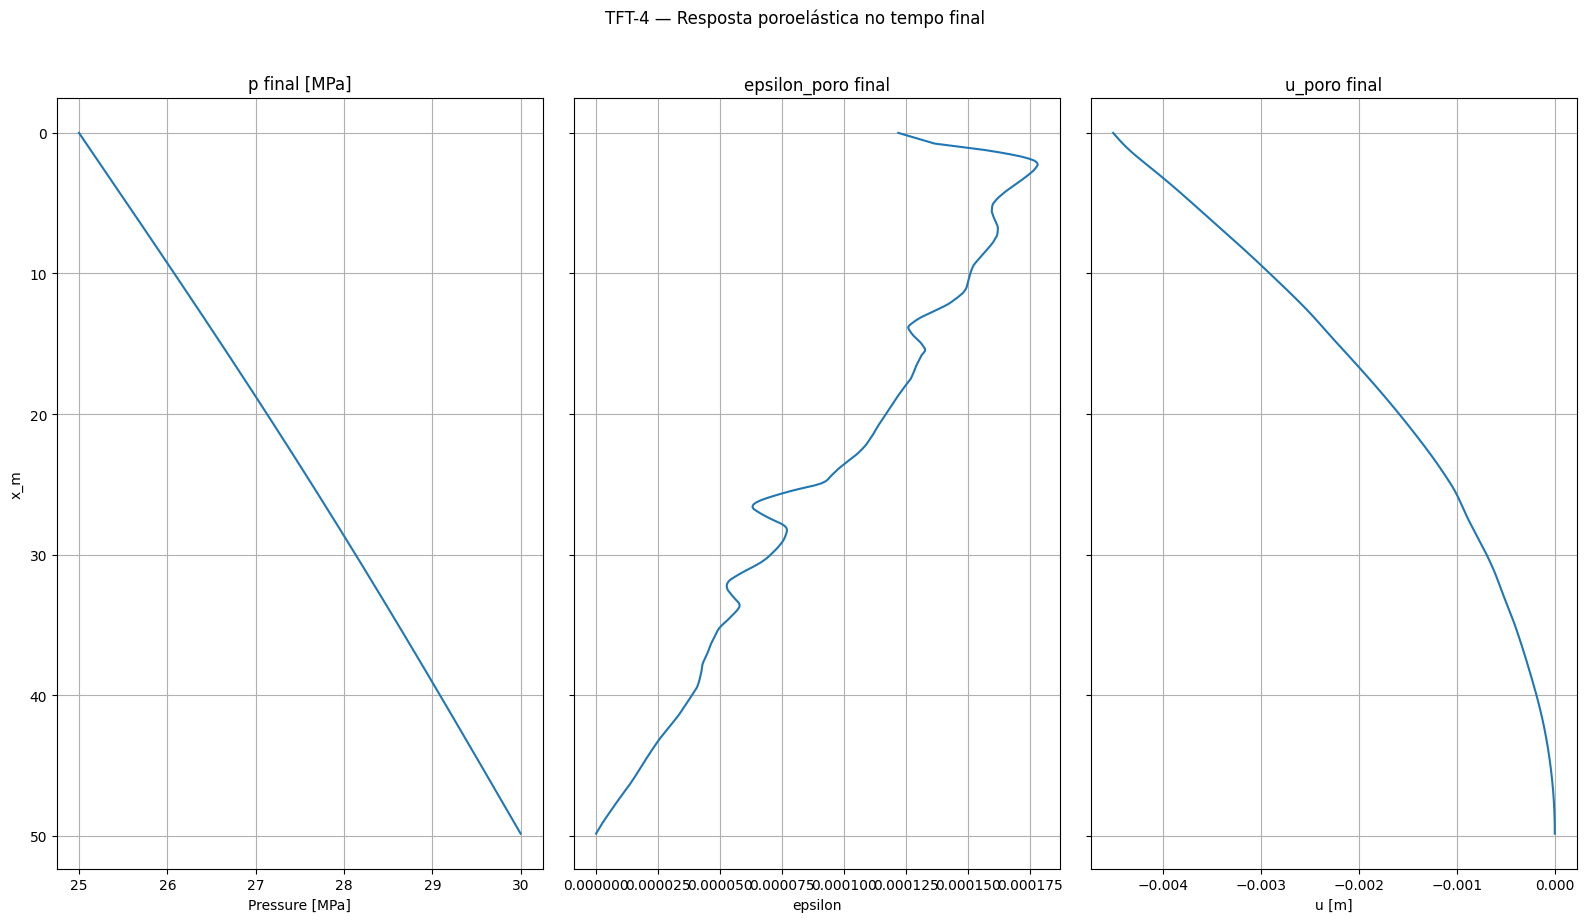

In [10]:
# Esta versão NÃO usa groupby.apply.
# Ela usa loop explícito para evitar perda de coluna step/time_s.

poro_frames = []

for step_value in sorted(pressure_history_df["step"].unique()):
    g = pressure_history_df[pressure_history_df["step"] == step_value].copy()
    g = g.sort_values("x_m").reset_index(drop=True)

    g["E_pa"] = np.interp(g["x_m"], e_df["x_m"], e_df["E_pa"])
    g["delta_p_pa"] = P_INITIAL - g["p_pa"]
    g["epsilon_poro"] = BIOT_ALPHA * g["delta_p_pa"] / g["E_pa"]

    g = integrate_displacement_from_strain_explicit(g)

    # Garantia explícita
    g["step"] = int(step_value)
    g["time_s"] = float(g["time_s"].iloc[0])

    poro_frames.append(g)

poro_history_df = pd.concat(poro_frames, ignore_index=True)

required_cols = [
    "x_m", "p_pa", "step", "time_s", "E_pa",
    "delta_p_pa", "epsilon_poro", "u_poro_m", "sigma_effective_pa"
]

missing_cols = [c for c in required_cols if c not in poro_history_df.columns]
if missing_cols:
    raise ValueError(f"Colunas ausentes em poro_history_df: {missing_cols}")

poro_history_df = poro_history_df[required_cols].copy()
poro_history_df["step"] = poro_history_df["step"].astype(int)
poro_history_df["time_s"] = poro_history_df["time_s"].astype(float)
poro_history_df = poro_history_df.sort_values(["step", "x_m"]).reset_index(drop=True)

display(poro_history_df.head())
display(poro_history_df.tail())
print("Colunas:", poro_history_df.columns.tolist())

last_step = int(poro_history_df["step"].max())
last_df = poro_history_df[poro_history_df["step"] == last_step].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

axes[0].plot(last_df["p_pa"] / 1e6, last_df["x_m"])
axes[0].set_title("p final [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].plot(last_df["epsilon_poro"], last_df["x_m"])
axes[1].set_title("epsilon_poro final")
axes[1].set_xlabel("epsilon")

axes[2].plot(last_df["u_poro_m"], last_df["x_m"])
axes[2].set_title("u_poro final")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
fig.suptitle(f"{WELL_NAME} — Resposta poroelástica no tempo final", y=1.02)
plt.tight_layout()
plt.show()

## Interpretação

Agora a queda de pressão foi convertida em resposta mecânica.

A lógica física usada foi:

```text
maior queda de pressão → maior deformação
menor E → maior deformação
```

O deslocamento foi integrado com base fixa.

# STEP 10 — Time Evolution Plots

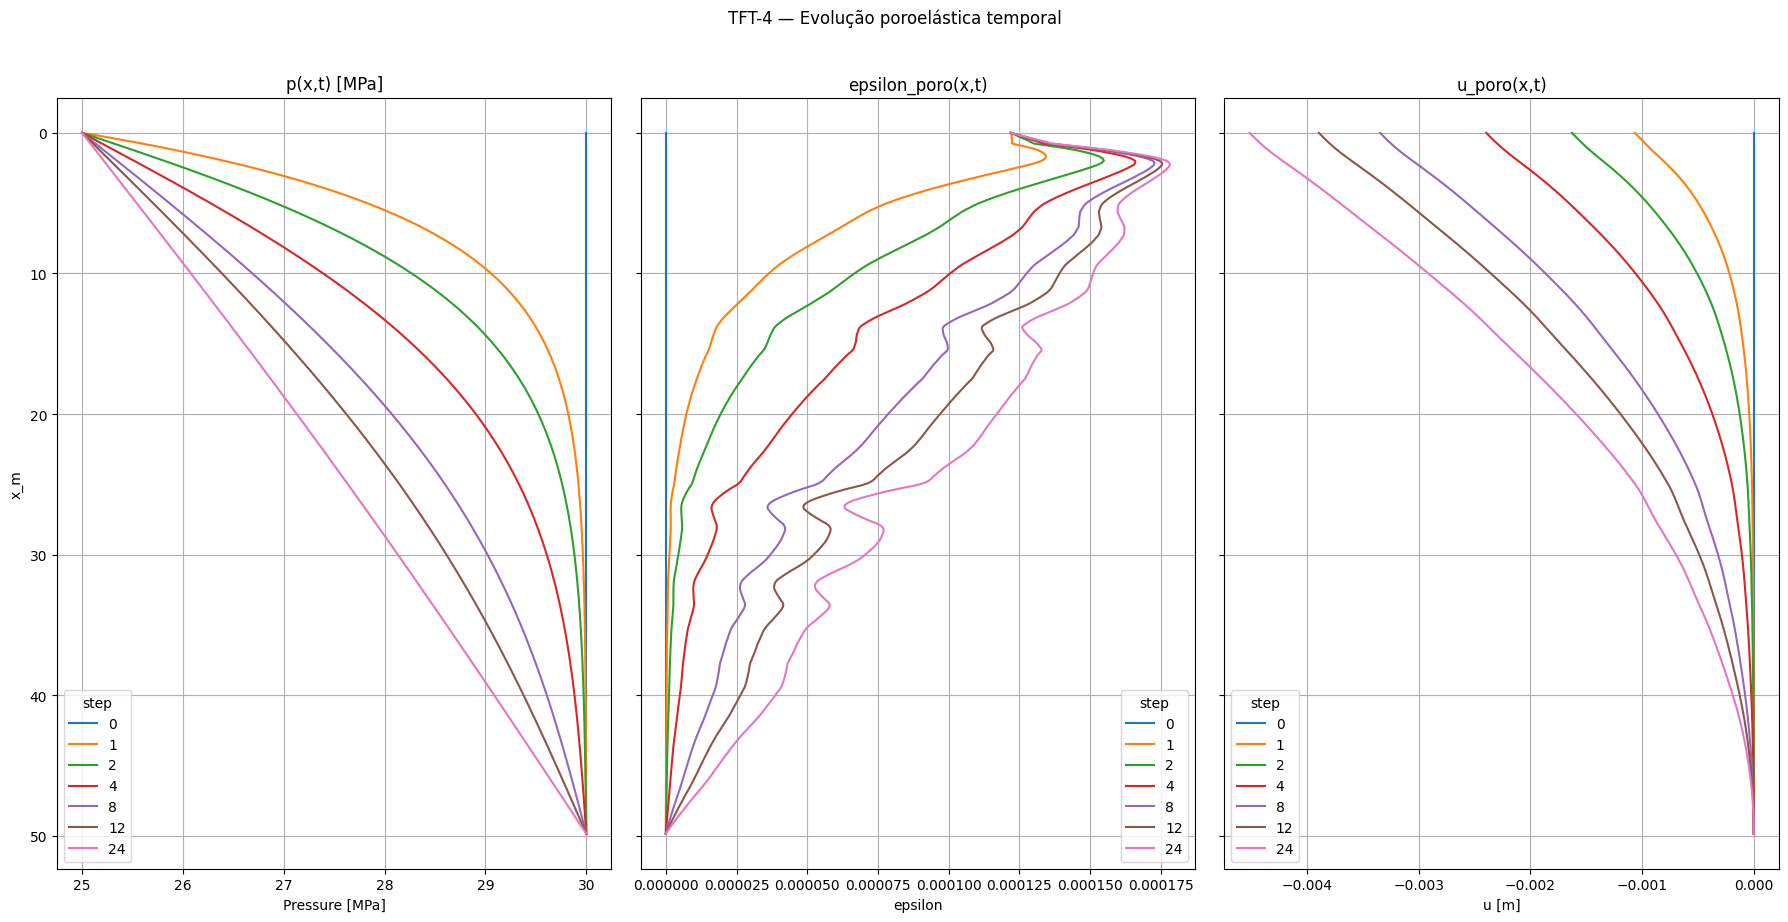

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=True)

for step_value in sorted(poro_history_df["step"].unique()):
    g = poro_history_df[poro_history_df["step"] == step_value]
    axes[0].plot(g["p_pa"] / 1e6, g["x_m"], label=f"{step_value}")
    axes[1].plot(g["epsilon_poro"], g["x_m"], label=f"{step_value}")
    axes[2].plot(g["u_poro_m"], g["x_m"], label=f"{step_value}")

axes[0].set_title("p(x,t) [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].set_title("epsilon_poro(x,t)")
axes[1].set_xlabel("epsilon")

axes[2].set_title("u_poro(x,t)")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)
    ax.legend(title="step")

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
fig.suptitle(f"{WELL_NAME} — Evolução poroelástica temporal", y=1.02)
plt.tight_layout()
plt.show()

## Interpretação

Agora vemos a evolução de pressão, deformação e deslocamento ao longo do tempo.

# STEP 11 — Convert x Back to Real Depth

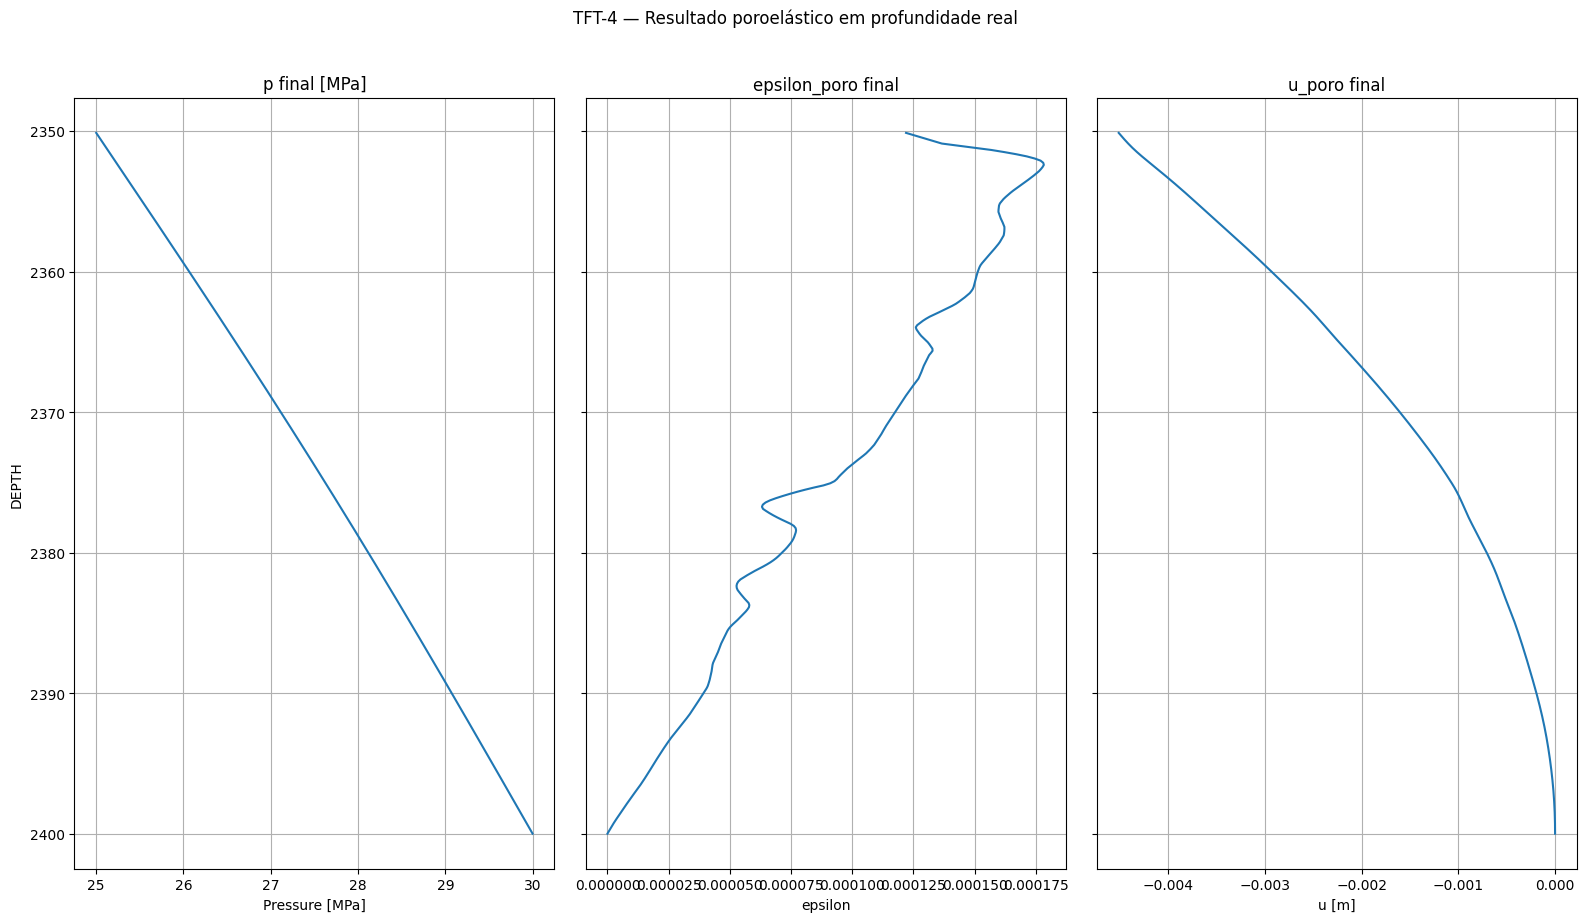

,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa,DEPTH,WELL
1974,0.000000,"25,000,000.000000",24,"86,400.000000","32,786,153,018.229519","5,000,000.000000",0.000122,-0.004514,"4,000,000.000000","2,350.136400",TFT-4
1975,0.152000,"25,016,479.044960",24,"86,400.000000","31,905,485,503.589760","4,983,520.955040",0.000125,-0.004495,"3,986,816.764032","2,350.288400",TFT-4
1976,0.304000,"25,032,957.976448",24,"86,400.000000","31,103,994,897.294281","4,967,042.023552",0.000128,-0.004476,"3,973,633.618842","2,350.440400",TFT-4
1977,0.456000,"25,049,436.681003",24,"86,400.000000","30,277,976,074.992485","4,950,563.318997",0.000131,-0.004456,"3,960,450.655197","2,350.592400",TFT-4
1978,0.608000,"25,065,915.045185",24,"86,400.000000","29,503,347,628.122078","4,934,084.954815",0.000134,-0.004436,"3,947,267.963852","2,350.744400",TFT-4


,x_m,p_pa,step,time_s,E_pa,delta_p_pa,epsilon_poro,u_poro_m,sigma_effective_pa,DEPTH,WELL
2298,49.248000,"29,943,959.112644",24,"86,400.000000","21,768,744,085.145435","56,040.887356",0.000002,-0.000001,"44,832.709885","2,399.384400",TFT-4
2299,49.400000,"29,957,969.730083",24,"86,400.000000","21,941,982,585.864567","42,030.269917",0.000002,-0.000000,"33,624.215933","2,399.536400",TFT-4
2300,49.552000,"29,971,980.008447",24,"86,400.000000","22,156,411,146.318531","28,019.991553",0.000001,-0.000000,"22,415.993242","2,399.688400",TFT-4
2301,49.704000,"29,985,990.060743",24,"86,400.000000","22,397,248,085.329918","14,009.939257",0.000001,-0.000000,"11,207.951406","2,399.840400",TFT-4
2302,49.856000,"30,000,000.000000",24,"86,400.000000","22,718,364,003.972057",0.000000,0.000000,0.000000,0.000000,"2,399.992400",TFT-4


In [12]:
depth_min = float(work_df["DEPTH"].min())

poro_history_df["DEPTH"] = poro_history_df["x_m"] + depth_min
poro_history_df["WELL"] = WELL_NAME

last_depth_df = poro_history_df[poro_history_df["step"] == poro_history_df["step"].max()].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

axes[0].plot(last_depth_df["p_pa"] / 1e6, last_depth_df["DEPTH"])
axes[0].set_title("p final [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].plot(last_depth_df["epsilon_poro"], last_depth_df["DEPTH"])
axes[1].set_title("epsilon_poro final")
axes[1].set_xlabel("epsilon")

axes[2].plot(last_depth_df["u_poro_m"], last_depth_df["DEPTH"])
axes[2].set_title("u_poro final")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("DEPTH")
fig.suptitle(f"{WELL_NAME} — Resultado poroelástico em profundidade real", y=1.02)
plt.tight_layout()
plt.show()

display(last_depth_df.head())
display(last_depth_df.tail())

## Interpretação

A resposta voltou para profundidade real.

Agora podemos interpretar a compactação por profundidade.

# STEP 12 — Summary Metrics

,WELL,STEP,TIME_S,TIME_H,P_MIN_MPA,P_MAX_MPA,DELTA_P_MAX_MPA,EPSILON_MAX,EPSILON_MEAN,U_TOP_M,U_BASE_M,SIGMA_EFFECTIVE_MAX_MPA
0,TFT-4,0,0.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,TFT-4,1,"3,600.000000",1.000000,25.000000,30.000000,5.000000,0.000135,0.000021,-0.001064,0.000000,4.000000
2,TFT-4,2,"7,200.000000",2.000000,25.000000,30.000000,5.000000,0.000155,0.000033,-0.001628,0.000000,4.000000
3,TFT-4,4,"14,400.000000",4.000000,25.000000,30.000000,5.000000,0.000166,0.000048,-0.002395,0.000000,4.000000
4,TFT-4,8,"28,800.000000",8.000000,25.000000,30.000000,5.000000,0.000173,0.000067,-0.003346,0.000000,4.000000
5,TFT-4,12,"43,200.000000",12.000000,25.000000,30.000000,5.000000,0.000175,0.000078,-0.003894,0.000000,4.000000
6,TFT-4,24,"86,400.000000",24.000000,25.000000,30.000000,5.000000,0.000178,0.000090,-0.004514,0.000000,4.000000


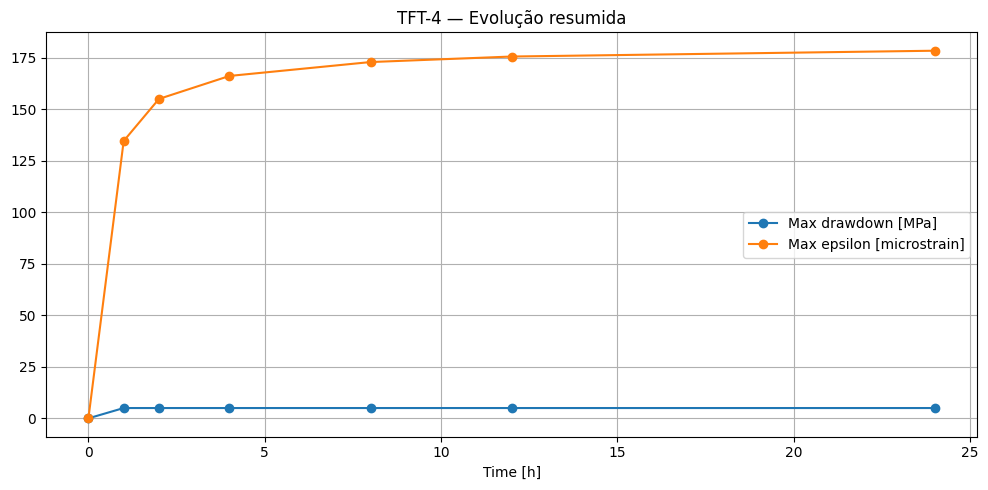

In [13]:
summary_rows = []

for step_value in sorted(poro_history_df["step"].unique()):
    g = poro_history_df[poro_history_df["step"] == step_value].copy()
    g = g.sort_values("x_m").reset_index(drop=True)

    summary_rows.append({
        "WELL": WELL_NAME,
        "STEP": int(step_value),
        "TIME_S": float(g["time_s"].iloc[0]),
        "TIME_H": float(g["time_s"].iloc[0] / 3600),
        "P_MIN_MPA": float(g["p_pa"].min() / 1e6),
        "P_MAX_MPA": float(g["p_pa"].max() / 1e6),
        "DELTA_P_MAX_MPA": float(g["delta_p_pa"].max() / 1e6),
        "EPSILON_MAX": float(g["epsilon_poro"].max()),
        "EPSILON_MEAN": float(g["epsilon_poro"].mean()),
        "U_TOP_M": float(g["u_poro_m"].iloc[0]),
        "U_BASE_M": float(g["u_poro_m"].iloc[-1]),
        "SIGMA_EFFECTIVE_MAX_MPA": float(g["sigma_effective_pa"].max() / 1e6),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("STEP").reset_index(drop=True)

display(summary_df)

plt.figure(figsize=(10, 5))
plt.plot(summary_df["TIME_H"], summary_df["DELTA_P_MAX_MPA"], "o-", label="Max drawdown [MPa]")
plt.plot(summary_df["TIME_H"], summary_df["EPSILON_MAX"] * 1e6, "o-", label="Max epsilon [microstrain]")
plt.xlabel("Time [h]")
plt.title(f"{WELL_NAME} — Evolução resumida")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretação

A tabela mostra a evolução temporal resumida.

Ela ajuda a comparar cenários de produção/depleção futuramente.

# STEP 13 — Export Results

In [14]:
safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

simulation_path = DATA_SIMULATION_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_history_v3.parquet"
summary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_summary_v3.csv"
params_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_parameters_v3.csv"

poro_history_df.to_parquet(simulation_path, index=False)
summary_df.to_csv(summary_path, index=False)
params_df.to_csv(params_path, index=False)

column_dictionary = pd.DataFrame({
    "COLUMN": poro_history_df.columns,
    "DTYPE": [str(poro_history_df[c].dtype) for c in poro_history_df.columns],
    "NON_NULL_COUNT": [poro_history_df[c].notna().sum() for c in poro_history_df.columns],
    "NULL_COUNT": [poro_history_df[c].isna().sum() for c in poro_history_df.columns],
    "FILL_RATE": [poro_history_df[c].notna().mean() for c in poro_history_df.columns],
})

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_column_dictionary_v3.csv"
column_dictionary.to_csv(column_dictionary_path, index=False)

print("SIMULAÇÃO POROELÁSTICA EXPORTADA COM SUCESSO!")
print(f"Histórico parquet: {simulation_path}")
print(f"Resumo: {summary_path}")
print(f"Parâmetros: {params_path}")
print(f"Dicionário: {column_dictionary_path}")

display(summary_df)
display(column_dictionary)

SIMULAÇÃO POROELÁSTICA EXPORTADA COM SUCESSO!
Histórico parquet: ../data/simulation/parquet/single_well_fenicsx_poroelasticity_1d/TFT-4_fenicsx_poroelasticity_1d_history_v3.parquet
Resumo: ../reports/single_well_fenicsx_poroelasticity_1d/TFT-4_fenicsx_poroelasticity_1d_summary_v3.csv
Parâmetros: ../reports/single_well_fenicsx_poroelasticity_1d/TFT-4_fenicsx_poroelasticity_1d_parameters_v3.csv
Dicionário: ../reports/single_well_fenicsx_poroelasticity_1d/TFT-4_fenicsx_poroelasticity_1d_column_dictionary_v3.csv


,WELL,STEP,TIME_S,TIME_H,P_MIN_MPA,P_MAX_MPA,DELTA_P_MAX_MPA,EPSILON_MAX,EPSILON_MEAN,U_TOP_M,U_BASE_M,SIGMA_EFFECTIVE_MAX_MPA
0,TFT-4,0,0.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,TFT-4,1,"3,600.000000",1.000000,25.000000,30.000000,5.000000,0.000135,0.000021,-0.001064,0.000000,4.000000
2,TFT-4,2,"7,200.000000",2.000000,25.000000,30.000000,5.000000,0.000155,0.000033,-0.001628,0.000000,4.000000
3,TFT-4,4,"14,400.000000",4.000000,25.000000,30.000000,5.000000,0.000166,0.000048,-0.002395,0.000000,4.000000
4,TFT-4,8,"28,800.000000",8.000000,25.000000,30.000000,5.000000,0.000173,0.000067,-0.003346,0.000000,4.000000
5,TFT-4,12,"43,200.000000",12.000000,25.000000,30.000000,5.000000,0.000175,0.000078,-0.003894,0.000000,4.000000
6,TFT-4,24,"86,400.000000",24.000000,25.000000,30.000000,5.000000,0.000178,0.000090,-0.004514,0.000000,4.000000


,COLUMN,DTYPE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE
0,x_m,float64,2303,0,1.000000
1,p_pa,float64,2303,0,1.000000
2,step,int64,2303,0,1.000000
3,time_s,float64,2303,0,1.000000
4,E_pa,float64,2303,0,1.000000
5,delta_p_pa,float64,2303,0,1.000000
6,epsilon_poro,float64,2303,0,1.000000
7,u_poro_m,float64,2303,0,1.000000
8,sigma_effective_pa,float64,2303,0,1.000000
9,DEPTH,float64,2303,0,1.000000


# STEP 14 — Final Interpretation

Este notebook executou uma primeira poroelasticidade 1D estável.

## O que foi feito

```text
physics-ready parquet
↓
malha 1D
↓
difusão de pressão com FEniCSx
↓
drawdown no topo
↓
p(x,t)
↓
epsilon_poro(x,t)
↓
u_poro(x,t)
↓
tensão efetiva aproximada
```

## O que este modelo já responde

- Como a pressão se dissipa na zona?
- Onde o drawdown é maior?
- Como a queda de pressão gera deformação?
- Onde a compactação tende a ser maior?
- Como a resposta evolui no tempo?

## Próximo avanço

O próximo passo científico será:

```text
05B.1 — Fully Coupled Biot 1D with FEniCSx
```

onde `u(x,t)` e `p(x,t)` serão resolvidos juntos em uma formulação mista.